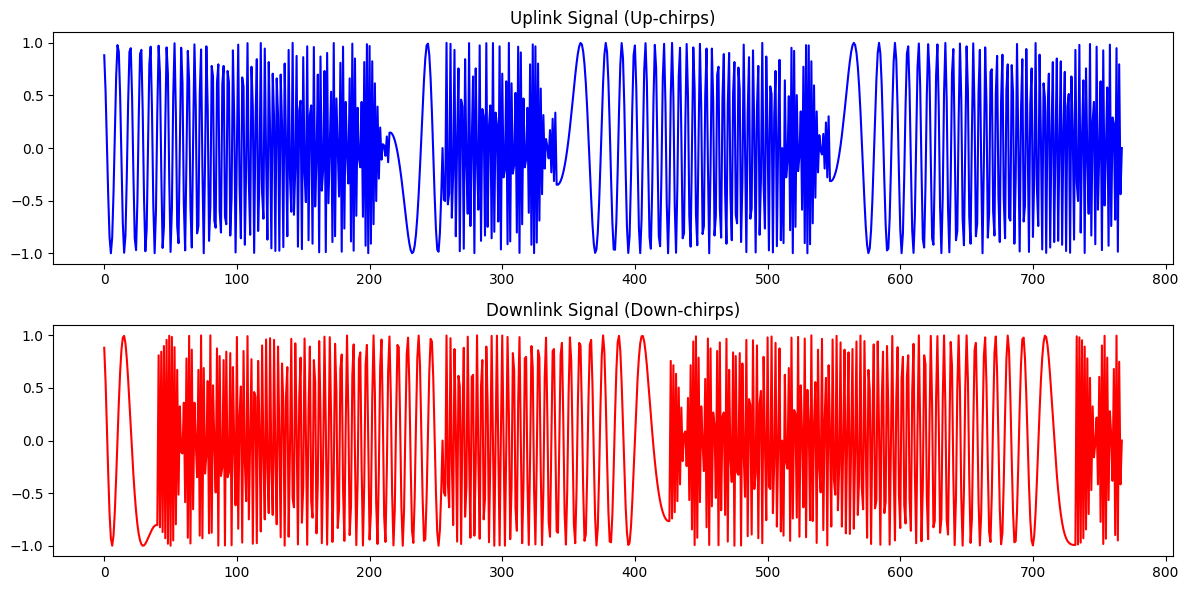

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_symbol(S, SF, BW, fs, is_uplink):
    Ts = (2**SF) / BW 
    f_offset = (S / (2**SF)) * BW 
    t = np.arange(0, Ts, 1/fs) 
    
    if is_uplink:
        f_inst = (f_offset + (BW / Ts) * t) % BW # Cyclic Up-chirp 
    else:
        f_inst = (f_offset - (BW / Ts) * t) % BW # Cyclic Down-chirp 
        
    phase = 2 * np.pi * np.cumsum(f_inst) * (1/fs)
    return np.cos(phase) # 

# Parameters
SF = 7
BW = 125e3 # Standard LoRa BW
fs = 250e3 
payload = [20, 85, 110] 

uplink_signal = np.concatenate([generate_symbol(S, SF, BW, fs, True) for S in payload])
downlink_signal = np.concatenate([generate_symbol(S, SF, BW, fs, False) for S in payload]) 

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(uplink_signal, color='blue')
plt.title("Uplink Signal (Up-chirps)")

plt.subplot(2, 1, 2)
plt.plot(downlink_signal, color='red')
plt.title("Downlink Signal (Down-chirps)")
plt.tight_layout()
plt.show()

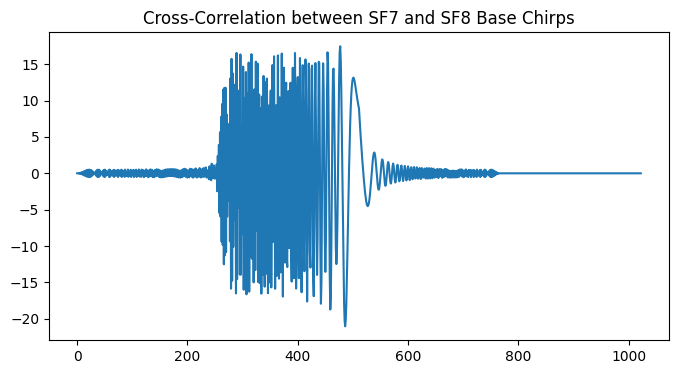

In [ ]:
import scipy.signal

sf7_chirp = generate_symbol(0, 7, BW, fs, True)
sf8_chirp = generate_symbol(0, 8, BW, fs, True)

pad_length = len(sf8_chirp) - len(sf7_chirp)
sf7_padded = np.pad(sf7_chirp, (0, pad_length), 'constant') 

cross_corr = scipy.signal.correlate(sf7_padded, sf8_chirp, mode='full')

plt.figure(figsize=(8, 4))
plt.plot(cross_corr)
plt.title("Cross-Correlation between SF7 and SF8 Base Chirps")
plt.show()